# Strategy: Costs, Markups, and Profit

## Imports

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [6]:
df = pd.read_csv("air_fryers_clean_brand_year.csv")
df.head()

,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364


In [7]:
y = df['log_brand_share']

brand_dummies = pd.get_dummies(df['brand'],drop_first=True, prefix="brand", dtype=int)
year_dummies = pd.get_dummies(df['year'],drop_first=True, prefix="year", dtype=int)
feature_cols = [
    'compact_share',
    'dual_basket_share',
    'oven_style_share',
    'rotisserie_share',
    'window_share']

X = pd.concat([df[['avg_price','avg_rating']+ feature_cols],brand_dummies,year_dummies],axis=1)

In [8]:
model = LinearRegression()
model.fit(X,y)

coef_table = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_})

**Q1: What are the average unit costs and markups for each brand over the years?**

In [11]:
coef_table = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_
})

price_coef = coef_table.loc[coef_table["feature"] == "avg_price", "coefficient"].iloc[0]
print("Estimated price coefficient:", price_coef)

results = df.copy()
results["demand_slope"] = price_coef * results["brand_share"] * (1 - results["brand_share"])
results["unit_cost"] = (results["avg_price"] + results["brand_share"] / results["demand_slope"])
results["markup"] = results["avg_price"] - results["unit_cost"]
results["average_profit"] = results["brand_share"] * results["markup"]
results["profit_derivative"] = (results["demand_slope"] * results["markup"] + results["brand_share"])

print(results[["unit_cost", "markup", "average_profit", "profit_derivative"]].describe())

Estimated price coefficient: -0.03766765298429383
        unit_cost     markup  average_profit  profit_derivative
count   50.000000  50.000000       50.000000       5.000000e+01
mean    93.102239  29.703894        3.155916       2.985893e-18
std     51.696080   2.615822        2.615822       1.753363e-17
min     22.002913  26.567362        0.019385      -2.775558e-17
25%     53.159061  27.952365        1.404387      -3.903128e-18
50%     70.038270  28.813285        2.265308       0.000000e+00
75%    123.561937  30.956852        4.408875       1.214306e-17
max    199.729962  37.507010       10.959033       5.551115e-17


In [12]:
brand_results = (results[["brand", "unit_cost", "markup", "average_profit"]].groupby("brand").mean())
brand_results

,unit_cost,markup,average_profit
brand,,,
chefman,61.569466,29.368946,2.820968
cosori,86.283321,27.984628,1.436651
cuisinart,194.896119,29.050974,2.502997
dash,27.936578,29.542349,2.994372
gowise usa,56.301040,31.153741,4.605764
instant_pot,71.903119,32.558234,6.010256
ninja,112.488470,32.854071,6.306093
nuwave,109.053549,27.970835,1.422858
oster,161.804969,27.226315,0.678338


Observations: Cuisinart has the highest average unit cost, followed by Oster, Ninja, and NuWave. Markups are fairly similar across brands, with Ninja and Instant Pot having the highest average markups.

**Q2: Are any inferred unit costs negative? If so, what might that mean?**

No, there are no negative inferred unit costs in this dataset. If there were, it would suggest issues with the estimation model or unusual data.

**Q3: Which brands have the highest average unit costs? How do average unit cost and average ratings compare? Make scatter plots of price vs. unit cost and average rating vs. unit cost. Do more expensive products have higher consumer satisfaction?**

In [13]:
brand_summary = (
    results[["brand", "unit_cost", "avg_rating"]].groupby("brand")
    .mean()
    .sort_values("unit_cost", ascending=False)
)

brand_summary

,unit_cost,avg_rating
brand,,
cuisinart,194.896119,4.438892
oster,161.804969,4.388653
ninja,112.488470,4.742064
nuwave,109.053549,4.389798
cosori,86.283321,4.656292
instant_pot,71.903119,4.559323
chefman,61.569466,4.427966
gowise usa,56.301040,4.576990
ultrean,48.785765,4.672616


Cuisinart, Oster, Ninja, and NuWave have the highest average unit costs. Higher unit cost does not clearly mean higher average rating, so more expensive products do not necessarily have higher consumer satisfaction.

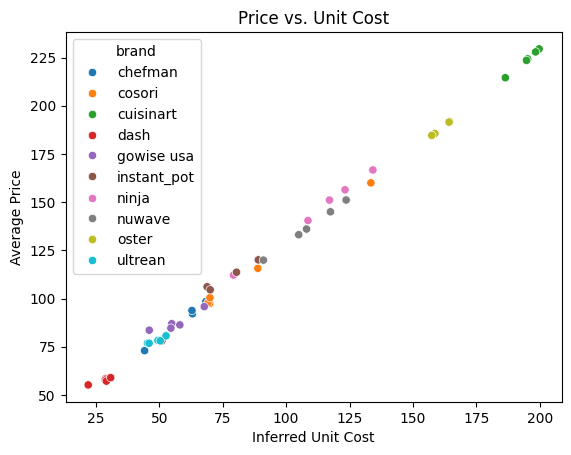

In [14]:
sns.scatterplot(data=results, x="unit_cost", y="avg_price", hue="brand")
plt.xlabel("Inferred Unit Cost")
plt.ylabel("Average Price")
plt.title("Price vs. Unit Cost")
plt.show()

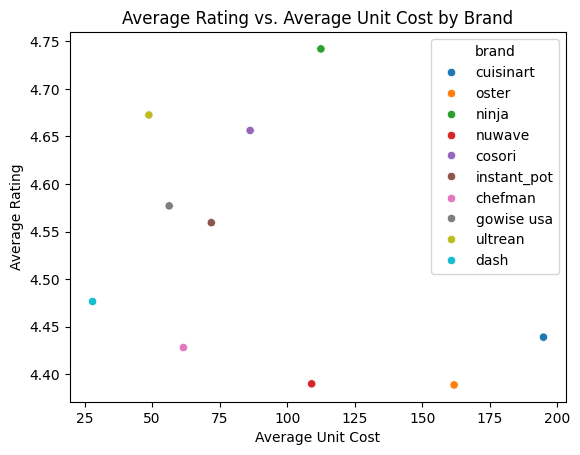

In [15]:
sns.scatterplot(data=brand_summary, x="unit_cost", y="avg_rating", hue="brand")
plt.xlabel("Average Unit Cost")
plt.ylabel("Average Rating")
plt.title("Average Rating vs. Average Unit Cost by Brand")
plt.show()

Observation: Higher unit cost does not clearly mean higher average rating, so more expensive products do not necessarily have higher consumer satisfaction.

**Q4: Make kernel density plots of unit costs, markups, and average profit, in general and hued by brand.**

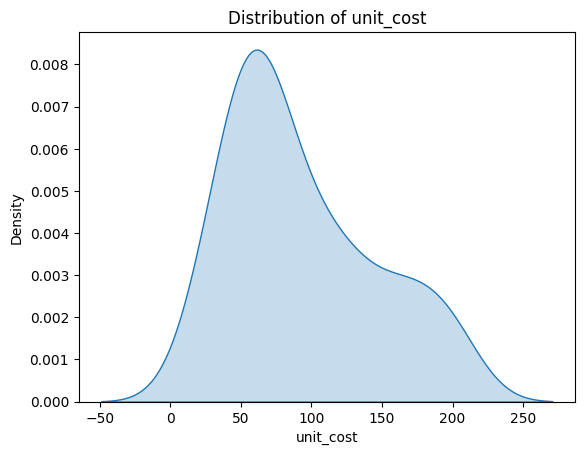

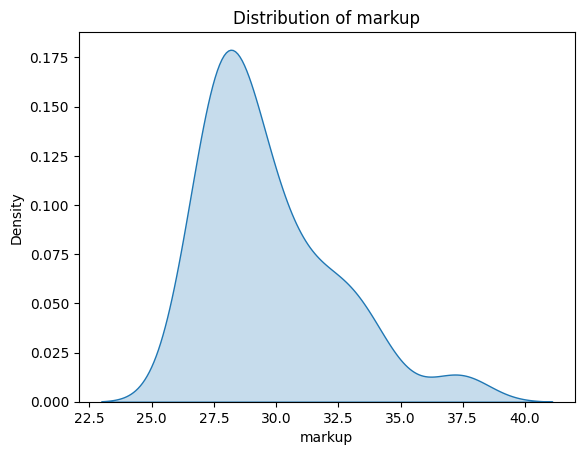

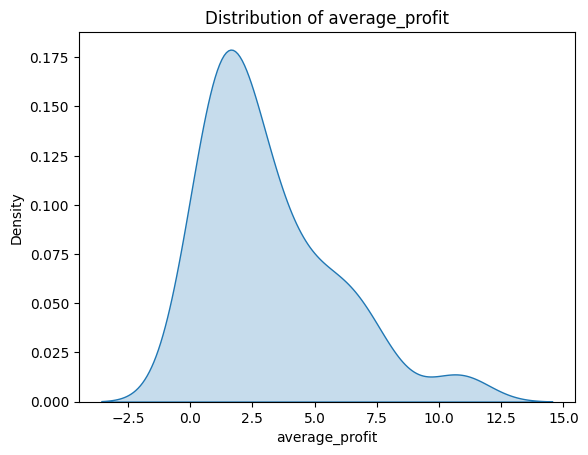

In [16]:
cols = ["unit_cost", "markup", "average_profit"]

for col in cols:
    sns.kdeplot(data=results, x=col, fill=True)
    plt.title(f"Distribution of {col}")
    plt.show()

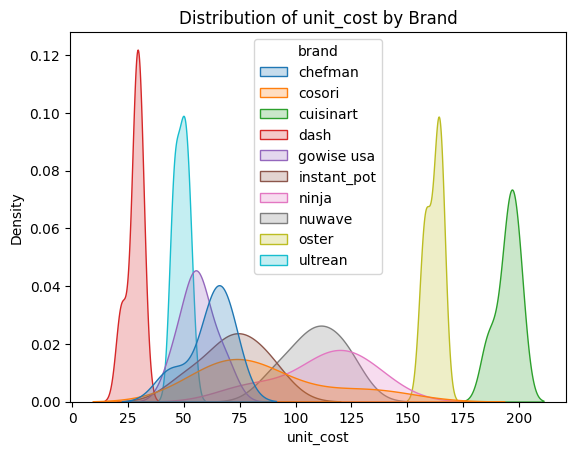

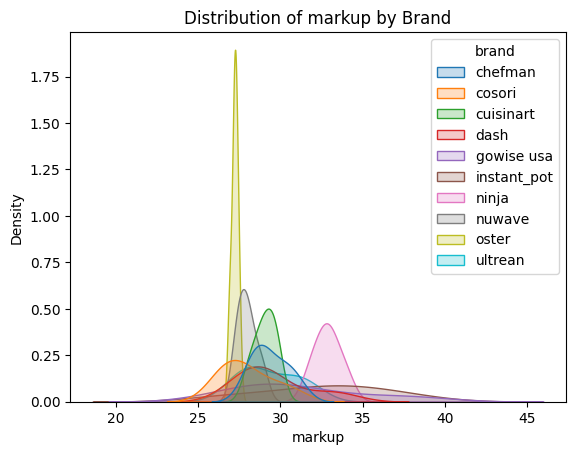

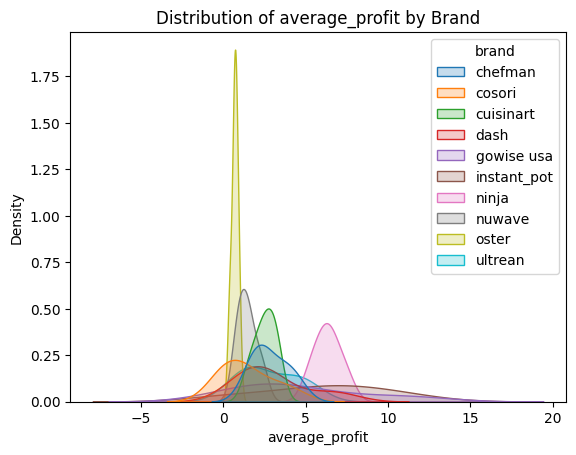

In [17]:
for col in cols:
    sns.kdeplot(data=results, x=col, hue="brand", fill=True, common_norm=False)
    plt.title(f"Distribution of {col} by Brand")
    plt.show()

Observation: The KDE plots show that unit costs vary more widely than markups. Markups are more tightly clustered, while average profit differs more by brand.

**Q5: Which brands have the highest share-weighted average profit?**

Ninja has the highest average profit, followed by Instant Pot and GoWise USA. Oster and NuWave have the lowest average profit.